In [1]:
import os
os.chdir("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipelines.catboost_pipe import CatBoostPipe

pipe = CatBoostPipe()

# All wheel force points plot

In [66]:
peaks = pipe.load("vertical_trials") # vertical_trials
peaks[:10]

[{'v': 20,
  'start_num': 541,
  'end_num': 546,
  'peaks': [23.0,
   23.0,
   23.0,
   103.44639587402344,
   111.8166275024414,
   121.29692077636719,
   115.62935638427734,
   115.62935638427734,
   350.0,
   350.0,
   23.0,
   350.0,
   100.6279067993164,
   88.69648742675781,
   95.7515869140625,
   86.8289566040039,
   200.05313110351562,
   73.45596313476562,
   313.4107666015625,
   350.0,
   93.01688385009766,
   94.30712890625,
   93.8770523071289,
   93.8770523071289,
   89.57621765136719,
   107.48865509033203,
   112.12576293945312,
   108.20999145507812,
   115.93849182128906,
   119.2359848022461,
   350.0,
   350.0,
   350.0,
   350.0,
   350.0,
   85.89519500732422,
   96.89285278320312,
   96.78910064697266,
   88.69648742675781,
   110.06929016113281,
   23.0,
   23.0,
   23.0,
   23.0,
   23.0,
   115.59623718261719,
   90.75894927978516,
   23.0,
   124.09038543701172,
   107.2825698852539,
   120.98778533935547,
   114.08364868164062,
   113.77450561523438,
   350

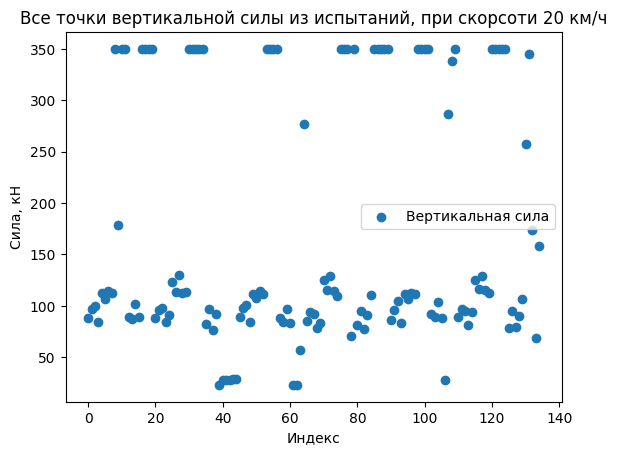

In [68]:
import scipy.signal

peaks_ = peaks[1]["peaks"]

plt.title("Все точки вертикальной силы из испытаний, при скорсоти 20 км/ч")
plt.scatter(range(len(peaks_)), peaks_, label="Вертикальная сила")
# plt.plot([np.median(peaks_) for _ in range(len(peaks_))],"-",c="r",label=f"median: {np.median(peaks_)}")
# удалить белый шум: пример двух подходов

# 1) Адаптивный локальный фильтр (Wiener)
wiener_smoothed = scipy.signal.wiener(peaks_, mysize=11)

# 2) Низкочастотный фильтр Баттерворта (устраняет высокочастотный шум)
b, a = scipy.signal.butter(3, 0.05)  # порядок 3, нормированная частота среза 0.05
butter_smoothed = scipy.signal.filtfilt(b, a, peaks_)

# plt.plot(wiener_smoothed, ".-", color="orange", label="Wiener denoise")
# plt.plot(butter_smoothed, "-", color="green", label="Butterworth LP")
plt.xlabel("Индекс")
plt.ylabel("Сила, кН")
plt.legend()
plt.show()

# Raw forces peaks plot

In [53]:
import numpy as np
from pathlib import Path

num = "0556"

file_path = f"/home/daniil_gorenkov/dissertation/Dissertation/data/signals/straight/signal{num}/А_1_2.dat"
mera_file = f"/home/daniil_gorenkov/dissertation/Dissertation/data/signals/straight/signal{num}/signal{num}.mera"         # подставь имя
channel = os.path.basename(file_path).split(".")[0]

# Читаем мета-информацию (если нужно)
import configparser
config = configparser.ConfigParser(allow_no_value=True)
config.read(mera_file, encoding='windows-1251')
print(config.sections())


['MERA', 'A_1_1', 'А_1_2', 'А_1_3', 'А_1_4', 'А_2_1', 'А_2_2', 'А_2_3', 'А_2_4', 'Б_1_1', 'Б_1_2', 'Б_1_3', 'Б_1_4', 'Б_2_1', 'Б_2_2', 'Б_2_3', 'Б_2_4', 'В_1_1', 'В_1_2', 'В_1_3', 'В_1_4', 'В_2_1', 'В_2_2', 'В_2_3', 'В_2_4', 'Г_1_1', 'Г_1_2', 'Г_1_3', 'Г_1_4', 'Г_2_1', 'Г_2_2', 'Г_2_3', 'Г_2_4', 'Д_1_1', 'Д_1_2', 'Д_1_3', 'Д_1_4', 'Д_2_1', 'Д_2_2', 'Д_2_3', 'Д_2_4', 'Е_1_1', 'Е_1_2', 'Е_1_3', 'Е_1_4', 'Е_2_1', 'Е_2_2', 'Е_2_3', 'Е_2_4']


In [54]:

freq = float(config[channel]['freq'])
k1 = float(config[channel].get('k1', 1.0))
k0 = float(config[channel].get('k0', 0.0))
start = float(config[channel].get('start', 0.0))
units = config[channel]['yunits']

# Чтение данных
raw = np.fromfile(file_path, dtype=np.float32)

physical = raw * k1 + k0

time = np.arange(len(physical)) / freq + start

print(f"Канал {channel}: {len(physical):,} точек, ~{len(physical)/freq/60:.1f} минут")
print(f"Первые значения (физические, {units}):", physical[:8])
print(f"Мин / макс: {physical.min():.2f} … {physical.max():.2f} {units}")

Канал А_1_2: 30,720 точек, ~0.2 минут
Первые значения (физические, кН): [0.10307083 0.17681137 0.16206326 0.16206326 0.2210557  0.05882651
 0.05882651 0.07357462]
Мин / макс: -8.66 … 11.62 кН


[20403 20759 23603 23958]


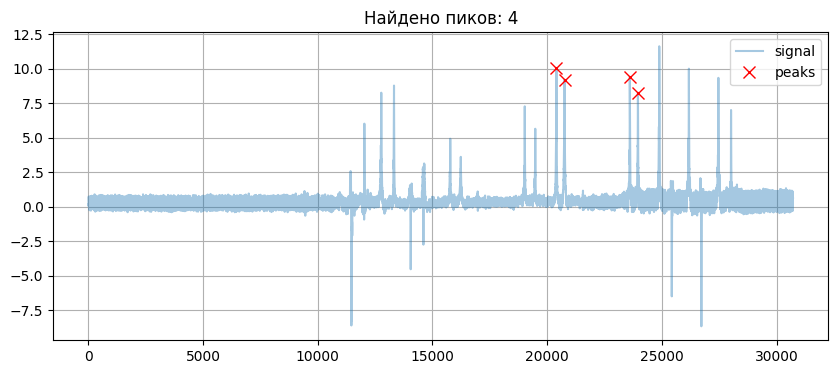

In [58]:
from scipy.signal import find_peaks

# signal_smooth = savgol_filter(signal, window_length=101, polyorder=3)

# ищем ОТРИЦАТЕЛЬНЫЕ пики
peaks, properties = find_peaks(
    physical,
    height=5,      # порог, подбери под свой шум
    distance=100      # минимальное расстояние между пиками
)

n = 5
m = 9
print(peaks[n:m])
plt.figure(figsize=(10, 4))

plt.plot(physical, alpha=0.4, label="signal")
# plt.plot(signal_smooth, linewidth=2, label="smooth")

plt.plot(
    peaks[n:m],
    physical[peaks[n:m]],
    "rx",
    markersize=8,
    label="peaks"
)

plt.legend()
plt.title(f"Найдено пиков: {len(peaks[n:m])}")
plt.grid(True)
plt.show()
